# FASE 2: Fine-tuning para Clasificación de Sarcasmo

**Objetivo**: Entrenar modelos BETO y XLM-RoBERTa para clasificación **binaria** de sarcasmo en español.

**Dataset**: Sarcastic_spanish_dataset (Ernesto-1997)
- **Clases**: 2 (SARCASMO, NO_SARCASMO)
- **Complejidad**: Menor que TASS (binario vs 3 clases)
- **F1 esperado**: Mayor que TASS

**⚠️ ESTE NOTEBOOK SE EJECUTA EN KAGGLE CON GPU T4**

---

## 📋 Pasos:
1. Verificación de entorno (GPU)
2. Instalación de librerías
3. Carga de datasets procesados (desde CSVs)
4. Autenticación HuggingFace
5. Fine-tuning BETO
6. Fine-tuning XLM-RoBERTa
7. Evaluación y comparación
8. Publicación en HuggingFace Hub
9. Guardado de resultados

**Modelos a publicar**:
- `Lucyan85/beto-sarcasmo-sentiment`
- `Lucyan85/xlmr-sarcasmo-sentiment`

---

## 1. Verificación de Entorno

In [45]:
import torch
import platform

print("\n🔧 VERIFICACIÓN DE ENTORNO")
print("="*70)

# Sistema operativo
print(f"Sistema operativo: {platform.system()} {platform.release()}")
print(f"Python: {platform.python_version()}")

# GPU
if torch.cuda.is_available():
    print(f"\n✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # Verificar CUDA capability (debe ser >= 7.0 para PyTorch actual)
    capability = torch.cuda.get_device_capability(0)
    capability_version = capability[0] + capability[1] / 10
    print(f"   CUDA capability: sm_{capability[0]}{capability[1]} (v{capability_version})")
    
    if capability_version < 7.0:
        print("\n❌ ERROR: GPU no compatible")
        print(f"   Tu GPU tiene CUDA capability {capability_version}")
        print(f"   PyTorch requiere CUDA capability >= 7.0")
        print("\n💡 SOLUCIÓN:")
        print("   En Kaggle: Settings → Accelerator → Cambiar a 'GPU T4'")
        print("   GPU T4 tiene CUDA capability 7.5 ✅")
        raise RuntimeError("GPU incompatible. Cambia a GPU T4 en Kaggle.")
    else:
        print(f"   ✅ CUDA capability compatible (>= 7.0)")
else:
    print("\n⚠️ GPU NO disponible - Entrenamiento será MUY lento")
    print("   Asegúrate de activar GPU en Kaggle: Settings → Accelerator → GPU T4")

print("="*70)
print("✅ Verificación completada\n")


🔧 VERIFICACIÓN DE ENTORNO
Sistema operativo: Linux 6.12.90+
Python: 3.12.13

✅ GPU disponible: Tesla T4
   CUDA version: 12.8
   Memoria GPU: 15.64 GB
   CUDA capability: sm_75 (v7.5)
   ✅ CUDA capability compatible (>= 7.0)
✅ Verificación completada



## 2. Instalación de Librerías

In [46]:
!pip install -q transformers datasets evaluate scikit-learn huggingface_hub
print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


## 3. Importar Librerías

In [47]:
# Librerías estándar
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# Transformers y datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
import evaluate

# HuggingFace Hub
from huggingface_hub import login, HfApi

# Scikit-learn
from sklearn.metrics import classification_report, confusion_matrix

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para solicitar token de forma segura
from getpass import getpass

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 4. Carga de Datasets Procesados

**⚠️ IMPORTANTE**: Debes haber subido los 3 CSVs a Kaggle como dataset:
- `sarcasmo_train.csv`
- `sarcasmo_validation.csv`
- `sarcasmo_test.csv`

Ajusta las rutas según donde los hayas ubicado en Kaggle.

In [48]:
# Rutas de los datasets en Kaggle
# Ajusta estas rutas según tu configuración en Kaggle
TRAIN_PATH = '/kaggle/input/datasets/julianquimbayocastro/sarcasmo-processed/sarcasmo_test.csv'
VAL_PATH = '/kaggle/input/datasets/julianquimbayocastro/sarcasmo-processed/sarcasmo_validation.csv'
TEST_PATH = '/kaggle/input/datasets/julianquimbayocastro/sarcasmo-processed/sarcasmo_test.csv'

print("\n📂 Cargando datasets procesados...")
print("="*70)

# Cargar CSVs
df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"✅ Train: {len(df_train)} muestras")
print(f"✅ Validation: {len(df_val)} muestras")
print(f"✅ Test: {len(df_test)} muestras")
print(f"\n📊 Total: {len(df_train) + len(df_val) + len(df_test)} muestras")

# Detectar columnas (mismo código que en exploración)
def detect_text_column(df):
    candidates = []
    for col in df.columns:
        if df[col].dtype == 'object':
            avg_length = df[col].astype(str).str.len().mean()
            if avg_length > 20:
                candidates.append((col, avg_length))
    if candidates:
        return max(candidates, key=lambda x: x[1])[0]
    return None

def detect_label_column(df, exclude_col=None):
    candidates = []
    for col in df.columns:
        if col != exclude_col:
            unique_count = df[col].nunique()
            if 2 <= unique_count <= 5:
                candidates.append((col, unique_count))
    if candidates:
        return min(candidates, key=lambda x: x[1])[0]
    return None

TEXT_COL = detect_text_column(df_train)
LABEL_COL = detect_label_column(df_train, exclude_col=TEXT_COL)

print(f"\n🔍 Columnas detectadas:")
print(f"   - Texto: '{TEXT_COL}'")
print(f"   - Etiqueta: '{LABEL_COL}'")

# Verificar clases (debe ser 2 para clasificación binaria)
classes = sorted(df_train[LABEL_COL].unique())
num_labels = len(classes)
print(f"\n🏷️ Clases: {classes}")
print(f"   - Número de clases: {num_labels}")

if num_labels != 2:
    print(f"\n⚠️ ADVERTENCIA: Se esperaban 2 clases pero se encontraron {num_labels}")
    print("   Verifica que el dataset sea de clasificación binaria")

# Crear mapeo de etiquetas a IDs
# ⚠️ IMPORTANTE: Convertir explícitamente a int() para evitar errores de serialización JSON
label2id = {label: int(idx) for idx, label in enumerate(classes)}
id2label = {int(idx): label for label, idx in label2id.items()}

print(f"\n📋 Mapeo de etiquetas:")
for label, idx in label2id.items():
    print(f"   {label} → {idx}")

print("="*70)


📂 Cargando datasets procesados...
✅ Train: 2292 muestras
✅ Validation: 2291 muestras
✅ Test: 2292 muestras

📊 Total: 6875 muestras

🔍 Columnas detectadas:
   - Texto: 'Texto'
   - Etiqueta: 'Sarcasmo'

🏷️ Clases: [np.int64(0), np.int64(1)]
   - Número de clases: 2

📋 Mapeo de etiquetas:
   0 → 0
   1 → 1


## 5. Autenticación HuggingFace

Token requerido con permisos de escritura: https://huggingface.co/settings/tokens

In [ ]:
print("Configuración de HuggingFace Hub")
print("-"*50)

try:
    # Intentar leer token desde archivo
    with open('/kaggle/input/hf-token/hf_token.txt', 'r') as f:
        hf_token = f.read().strip()
    print("Token leído desde archivo")
except FileNotFoundError:
    # Si no existe, solicitar manualmente
    hf_token = getpass("Ingresa tu token de HuggingFace: ")

# Autenticarse
try:
    login(token=hf_token)
    api = HfApi()
    user_info = api.whoami()
    username = user_info['name']
    print(f"\nAutenticado como: {username}")
except Exception as e:
    print(f"\nError en autenticación: {e}")
    raise

🔑 Configuración de HuggingFace Hub
📌 Tu token debe tener permisos de ESCRITURA
📌 Obtén tu token en: https://huggingface.co/settings/tokens



🔐 Ingresa tu token de HuggingFace:  ········



✅ Autenticado como: Lucyan85


## 6. Configuración de Entrenamiento

In [ ]:
# Hiperparámetros
MAX_LENGTH = 128
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
NUM_EPOCHS = 5
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01

print("\nConfiguración de Entrenamiento")
print("-"*50)
print(f"Max Length: {MAX_LENGTH} tokens")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Warmup Steps: {WARMUP_STEPS}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Early Stopping: 2 epochs")
print(f"FP16: {'Sí' if torch.cuda.is_available() else 'No'}")


⚙️ CONFIGURACIÓN DE ENTRENAMIENTO
Max Length: 128 tokens
Batch Size: 16
Learning Rate: 2e-05
Epochs: 5
Warmup Steps: 500
Weight Decay: 0.01
Early Stopping: 2 epochs de paciencia
Mixed Precision (FP16): Sí


## 7. Función de Entrenamiento y Evaluación

In [ ]:
# Métrica de evaluación
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Calcula accuracy y F1-score."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Para clasificación binaria, usar average='binary'
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    
    # Determinar qué clase es la positiva (generalmente la segunda, ID=1)
    pos_label = 1 if num_labels == 2 else None
    average = 'binary' if num_labels == 2 else 'weighted'
    
    f1 = f1_metric.compute(
        predictions=predictions, 
        references=labels,
        average=average,
        pos_label=pos_label
    )
    
    return {
        'accuracy': accuracy['accuracy'],
        'f1': f1['f1']
    }

def train_and_evaluate_model(
    model_name,
    hub_model_name,
    train_df,
    val_df,
    test_df,
    text_col,
    label_col,
    max_length=128,
    batch_size=16,
    learning_rate=2e-5,
    num_epochs=5,
    save_to_hub=True
):
    """
    Entrena y evalúa un modelo de clasificación de secuencias.
    
    Args:
        model_name: Nombre del modelo en HuggingFace (ej: 'dccuchile/bert-base-spanish-wwm-cased')
        hub_model_name: Nombre para publicar en HuggingFace Hub (ej: 'beto-sarcasmo-sentiment')
        train_df, val_df, test_df: DataFrames de pandas con los datos
        text_col: Nombre de la columna de texto
        label_col: Nombre de la columna de etiquetas
        max_length: Longitud máxima de tokenización
        batch_size: Tamaño del batch
        learning_rate: Tasa de aprendizaje
        num_epochs: Número de épocas
        save_to_hub: Si publicar el modelo en HuggingFace Hub
    
    Returns:
        dict: Diccionario con trainer, resultados y predicciones
    """
    
    print("\n" + "-"*70)
    print(f"Iniciando entrenamiento: {model_name}")
    print("-"*70)
    
    # 1. Cargar tokenizer y modelo
    print("\nCargando tokenizer y modelo...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Asegurar que num_labels, label2id e id2label tengan tipos correctos
    num_labels_int = int(num_labels)
    label2id_clean = {str(k): int(v) for k, v in label2id.items()}
    id2label_clean = {int(k): str(v) for k, v in id2label.items()}
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels_int,
        id2label=id2label_clean,
        label2id=label2id_clean
    )
    print(f"Modelo cargado: {model_name}")
    print(f"Parámetros: {model.num_parameters():,}")
    print(f"Num labels: {num_labels_int}")
    
    # 2. Preparar datasets
    print("\nTokenizando datasets...")
    
    # Convertir etiquetas a IDs (asegurar tipo int)
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()
    
    train_df['labels'] = train_df[label_col].map(label2id).astype(int)
    val_df['labels'] = val_df[label_col].map(label2id).astype(int)
    test_df['labels'] = test_df[label_col].map(label2id).astype(int)
    
    # Crear datasets de HuggingFace
    train_dataset = Dataset.from_pandas(train_df[[text_col, 'labels']])
    val_dataset = Dataset.from_pandas(val_df[[text_col, 'labels']])
    test_dataset = Dataset.from_pandas(test_df[[text_col, 'labels']])
    
    # Función de tokenización
    def tokenize_function(examples):
        return tokenizer(
            examples[text_col],
            truncation=True,
            padding=False,  # Padding dinámico con DataCollator
            max_length=max_length
        )
    
    # Tokenizar
    train_tokenized = train_dataset.map(tokenize_function, batched=True, remove_columns=[text_col])
    val_tokenized = val_dataset.map(tokenize_function, batched=True, remove_columns=[text_col])
    test_tokenized = test_dataset.map(tokenize_function, batched=True, remove_columns=[text_col])
    
    print(f"Tokenización completada")
    print(f"Train: {len(train_tokenized)} muestras")
    print(f"Val: {len(val_tokenized)} muestras")
    print(f"Test: {len(test_tokenized)} muestras")
    
    # 3. Data collator para padding dinámico
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # 4. Configurar argumentos de entrenamiento
    output_dir = f"./results_{hub_model_name.replace('/', '_')}"
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,  # Solo guardar 1 checkpoint para ahorrar espacio
        fp16=torch.cuda.is_available(),
        push_to_hub=save_to_hub,
        hub_model_id=hub_model_name,
        hub_strategy="end",
        logging_steps=50,
        report_to="none"
    )
    
    print("\nConfiguración de entrenamiento:")
    print(f"Output dir: {output_dir}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {learning_rate}")
    print(f"Épocas: {num_epochs}")
    print(f"FP16: {training_args.fp16}")
    print(f"Push to Hub: {save_to_hub}")
    if save_to_hub:
        print(f"Hub model: {hub_model_name}"))
    
    # 5. Crear Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    
    # 6. Entrenar
    print("\nIniciando entrenamiento...")
    print("Tiempo estimado: ~15-20 minutos\n")
    
    train_result = trainer.train()
    
    print("\nEntrenamiento completado")
    print(f"Tiempo: {train_result.metrics['train_runtime']:.2f}s")
    print(f"Loss final: {train_result.metrics['train_loss']:.4f}")
    
    # 7. Evaluar en validation
    print("\nEvaluando en validation set...")
    val_results = trainer.evaluate()
    print(f"Val Accuracy: {val_results['eval_accuracy']:.4f}")
    print(f"Val F1: {val_results['eval_f1']:.4f}")
    print(f"Val Loss: {val_results['eval_loss']:.4f}")
    
    # 8. Evaluar en test
    print("\nEvaluando en test set...")
    test_results = trainer.evaluate(test_tokenized)
    print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
    print(f"Test F1: {test_results['eval_f1']:.4f}")
    print(f"Test Loss: {test_results['eval_loss']:.4f}")
    
    # 9. Predicciones en test
    print("\nGenerando predicciones en test...")
    predictions = trainer.predict(test_tokenized)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = test_df['labels'].values
    
    # 10. Reporte de clasificación
    print("\nReporte de clasificación (Test):")
    print("-"*50)
    print(classification_report(
        y_true, 
        y_pred, 
        target_names=[id2label_clean[i] for i in range(num_labels_int)],
        digits=4
    ))
    
    # 11. Publicar en HuggingFace Hub
    if save_to_hub:
        print("\nPublicando en HuggingFace Hub...")
        try:
            trainer.push_to_hub(commit_message="Training completed")
            print(f"Modelo publicado: https://huggingface.co/{hub_model_name}")
        except Exception as e:
            print(f"Error al publicar: {e}")
    
    print("\n" + "-"*70)
    print(f"Entrenamiento completado: {model_name}")
    print("-"*70 + "\n")
    
    return {
        'trainer': trainer,
        'train_results': train_result.metrics,
        'val_results': val_results,
        'test_results': test_results,
        'predictions': predictions,
        'y_pred': y_pred,
        'y_true': y_true
    }

print("✅ Función de entrenamiento definida")

✅ Función de entrenamiento definida


## 8. Entrenar BETO

**Nota sobre espacio en disco**: Para evitar problemas de espacio en Kaggle, se configuró `save_total_limit=1` y se eliminan los checkpoints después del entrenamiento. Los modelos se publican en HuggingFace Hub antes de eliminar archivos locales.

In [ ]:
import shutil
import os
import glob

print("Limpieza inicial del disco")
print("-"*50)

checkpoint_dirs = glob.glob("./results_*") + glob.glob("./*-tass") + glob.glob("./*-sarcasmo")
total_freed = 0

print(f"\nCarpetas de checkpoints encontradas: {len(checkpoint_dirs)}")

for dir_path in checkpoint_dirs:
    if os.path.exists(dir_path) and os.path.isdir(dir_path):
        try:
            size = sum(os.path.getsize(os.path.join(dirpath, filename))
                      for dirpath, dirnames, filenames in os.walk(dir_path)
                      for filename in filenames)
            size_mb = size / (1024 * 1024)
            
            print(f"Eliminando: {dir_path} ({size_mb:.1f} MB)")
            shutil.rmtree(dir_path)
            total_freed += size_mb
        except Exception as e:
            print(f"No se pudo eliminar {dir_path}: {e}")

# Verificar espacio disponible
try:
    stat = os.statvfs('/kaggle/working')
    free_space_gb = (stat.f_bavail * stat.f_frsize) / (1024**3)
    print(f"\nLimpieza completada")
    print(f"Espacio liberado: ~{total_freed:.1f} MB")
    print(f"Espacio disponible: {free_space_gb:.2f} GB")
except:
    print(f"\nLimpieza completada")
    print(f"Espacio liberado: ~{total_freed:.1f} MB")

🧹 LIMPIEZA INICIAL DEL DISCO

📂 Carpetas de checkpoints encontradas: 4
   Eliminando: ./results_Lucyan85_beto-sarcasmo-sentiment (2935.9 MB)
   Eliminando: ./results_Lucyan85_xlmr-sarcasmo-sentiment (6624.9 MB)
   Eliminando: ./beto-tass (2935.9 MB)
   Eliminando: ./xlmr-tass (7473.1 MB)

✅ Limpieza completada
   - Espacio liberado: ~19969.9 MB
   - Espacio disponible: 19.50 GB
🚀 Listo para entrenar



## 7.5. Limpieza Inicial de Disco

Kaggle tiene espacio limitado (20GB). Esta celda elimina checkpoints de entrenamientos anteriores para prevenir errores de espacio insuficiente.

In [ ]:
# Entrenar BETO para Sarcasmo
MODEL_1_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO
HUB_MODEL_1 = "Lucyan85/beto-sarcasmo-sentiment"

results_beto = train_and_evaluate_model(
    model_name=MODEL_1_NAME,
    hub_model_name=HUB_MODEL_1,
    train_df=df_train,
    val_df=df_val,
    test_df=df_test,
    text_col=TEXT_COL,
    label_col=LABEL_COL,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    num_epochs=NUM_EPOCHS,
    save_to_hub=True
)

# Guardar referencias
trainer_beto = results_beto['trainer']

# Limpieza: Eliminar checkpoints para liberar espacio en disco
import shutil
import os

output_dir_beto = f"./results_{HUB_MODEL_1.replace('/', '_')}"
if os.path.exists(output_dir_beto):
    print(f"\nLiberando espacio: Eliminando checkpoints de {output_dir_beto}...")
    shutil.rmtree(output_dir_beto)
    print(f"Checkpoints eliminados.")


🚀 INICIANDO ENTRENAMIENTO: dccuchile/bert-base-spanish-wwm-cased

📥 Cargando tokenizer y modelo...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

✅ Modelo cargado: dccuchile/bert-base-spanish-wwm-cased
   - Parámetros: 109,852,418
   - Num labels: 2

🔄 Tokenizando datasets...


Map:   0%|          | 0/2292 [00:00<?, ? examples/s]

...

   - Val Accuracy: 0.8739
   - Val F1: 0.8368
   - Val Loss: 1.1780

📊 Evaluando en test set...
   - Test Accuracy: 0.9965
   - Test F1: 0.9956
   - Test Loss: 0.0201

🔮 Generando predicciones en test...

📋 REPORTE DE CLASIFICACIÓN (TEST):
              precision    recall  f1-score   support

           0     0.9942    1.0000    0.9971      1375
           1     1.0000    0.9913    0.9956       917

    accuracy                         0.9965      2292
   macro avg     0.9971    0.9956    0.9964      2292
weighted avg     0.9965    0.9965    0.9965      2292


🌐 Publicando en HuggingFace Hub...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Modelo publicado: https://huggingface.co/Lucyan85/beto-sarcasmo-sentiment

✅ ENTRENAMIENTO COMPLETADO: dccuchile/bert-base-spanish-wwm-cased


🧹 Liberando espacio: Eliminando checkpoints de ./results_Lucyan85_beto-sarcasmo-sentiment...
✅ Checkpoints eliminados. Espacio liberado para el siguiente modelo.


## 9. Entrenar XLM-RoBERTa

In [ ]:
# Entrenar XLM-RoBERTa para Sarcasmo
MODEL_2_NAME = "xlm-roberta-base"
HUB_MODEL_2 = "Lucyan85/xlmr-sarcasmo-sentiment"

results_xlmr = train_and_evaluate_model(
    model_name=MODEL_2_NAME,
    hub_model_name=HUB_MODEL_2,
    train_df=df_train,
    val_df=df_val,
    test_df=df_test,
    text_col=TEXT_COL,
    label_col=LABEL_COL,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    num_epochs=NUM_EPOCHS,
    save_to_hub=True
)

# Guardar referencias
trainer_xlmr = results_xlmr['trainer']

# Limpieza: Eliminar checkpoints para liberar espacio en disco
output_dir_xlmr = f"./results_{HUB_MODEL_2.replace('/', '_')}"
if os.path.exists(output_dir_xlmr):
    print(f"\nLiberando espacio: Eliminando checkpoints de {output_dir_xlmr}...")
    shutil.rmtree(output_dir_xlmr)
    print(f"Checkpoints eliminados.")


🚀 INICIANDO ENTRENAMIENTO: xlm-roberta-base

📥 Cargando tokenizer y modelo...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modelo cargado: xlm-roberta-base
   - Parámetros: 278,045,186
   - Num labels: 2

🔄 Tokenizando datasets...


Map:   0%|          | 0/2292 [00:00<?, ? examples/s]

...

   - Val Accuracy: 0.8477
   - Val F1: 0.8009
   - Val Loss: 0.8402

📊 Evaluando en test set...
   - Test Accuracy: 0.9524
   - Test F1: 0.9391
   - Test Loss: 0.2949

🔮 Generando predicciones en test...

📋 REPORTE DE CLASIFICACIÓN (TEST):
              precision    recall  f1-score   support

           0     0.9464    0.9760    0.9610      1375
           1     0.9622    0.9171    0.9391       917

    accuracy                         0.9524      2292
   macro avg     0.9543    0.9466    0.9501      2292
weighted avg     0.9527    0.9524    0.9522      2292


🌐 Publicando en HuggingFace Hub...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Modelo publicado: https://huggingface.co/Lucyan85/xlmr-sarcasmo-sentiment

✅ ENTRENAMIENTO COMPLETADO: xlm-roberta-base


🧹 Liberando espacio: Eliminando checkpoints de ./results_Lucyan85_xlmr-sarcasmo-sentiment...
✅ Checkpoints eliminados.


## 10. Comparación de Modelos

In [ ]:
print("\n" + "-"*70)
print("Comparación de Modelos - Clasificación Sarcasmo")
print("-"*70 + "\n")

# Crear DataFrame de comparación
comparison_data = [
    {
        'Modelo': 'BETO',
        'Val Accuracy': results_beto['val_results']['eval_accuracy'],
        'Val F1': results_beto['val_results']['eval_f1'],
        'Test Accuracy': results_beto['test_results']['eval_accuracy'],
        'Test F1': results_beto['test_results']['eval_f1'],
        'Test Loss': results_beto['test_results']['eval_loss'],
        'Tiempo (s)': results_beto['train_results']['train_runtime']
    },
    {
        'Modelo': 'XLM-RoBERTa',
        'Val Accuracy': results_xlmr['val_results']['eval_accuracy'],
        'Val F1': results_xlmr['val_results']['eval_f1'],
        'Test Accuracy': results_xlmr['test_results']['eval_accuracy'],
        'Test F1': results_xlmr['test_results']['eval_f1'],
        'Test Loss': results_xlmr['test_results']['eval_loss'],
        'Tiempo (s)': results_xlmr['train_results']['train_runtime']
    }
]

df_comparison = pd.DataFrame(comparison_data)

print("Tabla de Comparación:")
print(df_comparison.to_string(index=False))

# Identificar mejor modelo
best_model_idx = df_comparison['Test F1'].idxmax()
best_model_name = df_comparison.loc[best_model_idx, 'Modelo']
best_f1 = df_comparison.loc[best_model_idx, 'Test F1']

print(f"\nMejor Modelo: {best_model_name}")
print(f"Test F1: {best_f1:.4f}")
print(f"Test Accuracy: {df_comparison.loc[best_model_idx, 'Test Accuracy']:.4f}")

# Guardar comparación
df_comparison.to_csv('sarcasmo_results_comparison.csv', index=False)
print("\nComparación guardada: sarcasmo_results_comparison.csv")

print("\n" + "-"*70)


📊 COMPARACIÓN DE MODELOS - CLASIFICACIÓN SARCASMO

📋 Tabla de Comparación:
     Modelo  Val Accuracy   Val F1  Test Accuracy  Test F1  Test Loss  Tiempo (s)
       BETO      0.873854 0.836815       0.996510 0.995619   0.020060    121.4778
XLM-RoBERTa      0.847665 0.800913       0.952443 0.939140   0.294947    235.5011

🏆 MEJOR MODELO: BETO
   - Test F1: 0.9956
   - Test Accuracy: 0.9965

💾 Comparación guardada: sarcasmo_results_comparison.csv



## 11. Matrices de Confusión

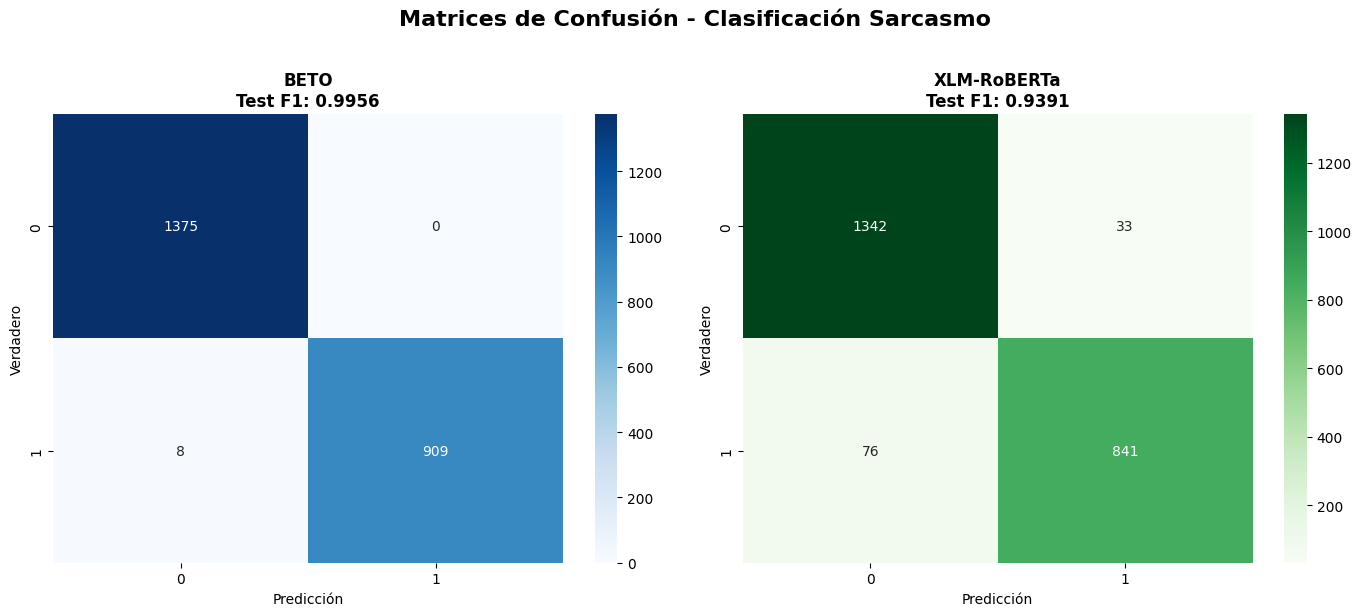

💾 Matrices guardadas: confusion_matrices_sarcasmo.png


In [ ]:
# Generar matrices de confusión para ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BETO
cm_beto = confusion_matrix(results_beto['y_true'], results_beto['y_pred'])
sns.heatmap(cm_beto, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes)
axes[0].set_title(f'BETO\nTest F1: {results_beto["test_results"]["eval_f1"]:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Verdadero')

# XLM-RoBERTa
cm_xlmr = confusion_matrix(results_xlmr['y_true'], results_xlmr['y_pred'])
sns.heatmap(cm_xlmr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=classes, yticklabels=classes)
axes[1].set_title(f'XLM-RoBERTa\nTest F1: {results_xlmr["test_results"]["eval_f1"]:.4f}', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Verdadero')

plt.suptitle('Matrices de Confusión - Clasificación Sarcasmo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_sarcasmo.png', dpi=300, bbox_inches='tight')
plt.show()

print("Matrices guardadas: confusion_matrices_sarcasmo.png")

## 12. Guardar Resultados Detallados

In [ ]:
# Función auxiliar para convertir tipos numpy a tipos nativos de Python
def convert_to_native_types(obj):
    """
    Convierte recursivamente todos los tipos numpy a tipos nativos de Python.
    Esto es necesario para la serialización JSON.
    """
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_native_types(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native_types(item) for item in obj]
    else:
        return obj

# Crear diccionario con todos los resultados
detailed_results = {
    'dataset': 'Sarcastic_spanish_dataset (Ernesto-1997)',
    'task': 'binary_classification',
    'num_classes': int(num_labels),  # Convertir explícitamente
    'classes': [str(c) for c in classes],  # Convertir a lista de strings
    'dataset_size': {
        'train': int(len(df_train)),
        'validation': int(len(df_val)),
        'test': int(len(df_test)),
        'total': int(len(df_train) + len(df_val) + len(df_test))
    },
    'hyperparameters': {
        'max_length': int(MAX_LENGTH),
        'batch_size': int(BATCH_SIZE),
        'learning_rate': float(LEARNING_RATE),
        'num_epochs': int(NUM_EPOCHS),
        'warmup_steps': int(WARMUP_STEPS),
        'weight_decay': float(WEIGHT_DECAY)
    },
    'models': {
        'beto': {
            'model_name': MODEL_1_NAME,
            'hub_name': HUB_MODEL_1,
            'train': {
                'runtime': float(results_beto['train_results']['train_runtime']),
                'loss': float(results_beto['train_results']['train_loss'])
            },
            'validation': {
                'accuracy': float(results_beto['val_results']['eval_accuracy']),
                'f1': float(results_beto['val_results']['eval_f1']),
                'loss': float(results_beto['val_results']['eval_loss'])
            },
            'test': {
                'accuracy': float(results_beto['test_results']['eval_accuracy']),
                'f1': float(results_beto['test_results']['eval_f1']),
                'loss': float(results_beto['test_results']['eval_loss'])
            }
        },
        'xlm_roberta': {
            'model_name': MODEL_2_NAME,
            'hub_name': HUB_MODEL_2,
            'train': {
                'runtime': float(results_xlmr['train_results']['train_runtime']),
                'loss': float(results_xlmr['train_results']['train_loss'])
            },
            'validation': {
                'accuracy': float(results_xlmr['val_results']['eval_accuracy']),
                'f1': float(results_xlmr['val_results']['eval_f1']),
                'loss': float(results_xlmr['val_results']['eval_loss'])
            },
            'test': {
                'accuracy': float(results_xlmr['test_results']['eval_accuracy']),
                'f1': float(results_xlmr['test_results']['eval_f1']),
                'loss': float(results_xlmr['test_results']['eval_loss'])
            }
        }
    },
    'best_model': {
        'name': str(best_model_name),
        'test_f1': float(best_f1),
        'test_accuracy': float(df_comparison.loc[best_model_idx, 'Test Accuracy'])
    }
}

# Aplicar conversión recursiva por si acaso
detailed_results = convert_to_native_types(detailed_results)

# Guardar como JSON
with open('sarcasmo_detailed_results.json', 'w', encoding='utf-8') as f:
    json.dump(detailed_results, f, indent=2, ensure_ascii=False)

print("Resultados detallados guardados: sarcasmo_detailed_results.json")

💾 Resultados detallados guardados: sarcasmo_detailed_results.json


## 13. Resumen Final

In [59]:
print("\n" + "="*70)
print("🎉 FASE 2 COMPLETADA - CLASIFICACIÓN SARCASMO")
print("="*70 + "\n")

print("✅ Modelos entrenados y publicados en HuggingFace Hub:")
print(f"   1. BETO: {HUB_MODEL_1}")
print(f"      https://huggingface.co/{HUB_MODEL_1}")
print(f"   2. XLM-RoBERTa: {HUB_MODEL_2}")
print(f"      https://huggingface.co/{HUB_MODEL_2}")

print("\n✅ Archivos generados:")
print("   - sarcasmo_results_comparison.csv")
print("   - sarcasmo_detailed_results.json")
print("   - confusion_matrices_sarcasmo.png")

print("\n📊 Mejor modelo:")
print(f"   - {best_model_name}")
print(f"   - Test F1: {best_f1:.4f}")
print(f"   - Test Accuracy: {df_comparison.loc[best_model_idx, 'Test Accuracy']:.4f}")




🎉 FASE 2 COMPLETADA - CLASIFICACIÓN SARCASMO

✅ Modelos entrenados y publicados en HuggingFace Hub:
   1. BETO: Lucyan85/beto-sarcasmo-sentiment
      https://huggingface.co/Lucyan85/beto-sarcasmo-sentiment
   2. XLM-RoBERTa: Lucyan85/xlmr-sarcasmo-sentiment
      https://huggingface.co/Lucyan85/xlmr-sarcasmo-sentiment

✅ Archivos generados:
   - sarcasmo_results_comparison.csv
   - sarcasmo_detailed_results.json
   - confusion_matrices_sarcasmo.png

📊 Mejor modelo:
   - BETO
   - Test F1: 0.9956
   - Test Accuracy: 0.9965
